In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [3]:
import os
import sys
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from copy import deepcopy
import numpy as np
from cogwheel import gw_utils, utils, data

sys.path.insert(0, '/home/abbye.williams/GWPE/code')
import helpers

In [4]:
def compute_max_lnlikes(sampler, verbose=True):
    # injection parameters
    like = sampler.posterior.likelihood
    ed = like.event_data
    injected_par_dic = ed.injection['par_dic']
    iota = injected_par_dic['iota']
    rho = np.sqrt(np.sum(ed.injection['h_h']))
    if verbose:
        print(f"{ed.eventname}: SNR is {rho:.1f}")
        print(f"inclination is {iota / np.pi:.2f}π")

    # zero noise realization
    ed_u_0 = ed.reinstantiate(strain=np.zeros_like(ed.strain))
    ed_u_0.inject_signal(par_dic=injected_par_dic, approximant=approximant)
    like_u_0 = sampler.posterior.likelihood
    like_u_0.event_data = ed_u_0
    like_u_0._set_summary()
    like_u_0.asd_drift = None

    # Type II lens
    ed_0 = ed_u_0.reinstantiate(strain=ed_u_0.strain * 1j)
    like_0 = deepcopy(like_u_0)
    like_0.event_data = ed_0
    like_0._set_summary()
    like_0.asd_drift = None

    # what's the likelihood of the unlensed event data given the injected parameters?
    maxlnlike_u = like_u_0.lnlike_fft(injected_par_dic)
    print(f"max ln likelihood of the unlensed data given injected parameters is {maxlnlike_u:.1f}")

    # what's the likelihood of the lensed event data given the imposter parameters?
    shifts = [+np.pi/4, -np.pi/4]
    shift_strs = ['+ pi/4', '- pi/4']
    maxlnlikes = []
    for shift_str, shift in zip(shift_strs, shifts):
        maxlnlike_imposter = like_0.lnlike_fft(injected_par_dic | dict(psi=injected_par_dic['psi'] + shift))
        if verbose:
            print(f"max ln likelihood of the lensed (zero-noise) data given unlensed imposter (psi -> psi {shift_str}) is {maxlnlike_imposter:.1f}")
        maxlnlikes.append(maxlnlike_imposter)
    # take the max
    idx_max = np.argmax(maxlnlikes)
    maxlnlike_imposter = maxlnlikes[idx_max]
    shift = shifts[idx_max]
    if verbose:
        print(f"taking psi {shift_strs[idx_max]} as the best imposter")
    
    # maximize the likelihood over distance given the unlensed imposter
    maxD_res = helpers.max_over_distance(like_0, injected_par_dic, shift)
    maxlnlike_imposter_dL = -maxD_res['fun']
    if verbose:
        print(f"max ln likelihood given imposter, maximized over distance, is {maxlnlike_imposter_dL:.1f} at {maxD_res['x']:.1f} Mpc")

    maxlnlike_diff = maxlnlike_u - maxlnlike_imposter_dL
    lnlike_mismatch = (maxlnlike_u - maxlnlike_imposter_dL) / rho**2
    print(f"max lnlike difference (mismatch) = {maxlnlike_diff:.1f} ({lnlike_mismatch:.3f})")

    ## EXPECTED SCALING FROM FORMULA ##
    # waveform (frequency domain) in each detector
    # HH = helpers.compute_HH(like_0)

    # antenna response functions
    # init_dict = ed.get_init_dict()
    # fplus, fcross = gw_utils.fplus_fcross(init_dict['detector_names'],
    #                                         injected_par_dic['ra'], injected_par_dic['dec'],
    #                                         injected_par_dic['psi'], init_dict['tgps'])

    # # then the expected ln Bayes
    # mu = np.cos(injected_par_dic['iota'])
    # formula_mismatch = helpers.expected_mismatch_with_HH(fplus, fcross, mu, HH)
    # expected_lnB = rho**2 * formula_mismatch
    # print(f"expected lnB (mismatch) from formula = {expected_lnB:.2f} ({formula_mismatch:.3f})")

    res = {
        'lnlike_mismatch' : lnlike_mismatch,
        # 'formula_mismatch' : formula_mismatch,
        'shift' : shift,
        # 'HH' : HH,
        'rhosq' : rho**2,
        'max_lnlike_unlensed' : maxlnlike_u,
        'max_lnlike_imposter' : maxlnlike_imposter_dL
    }

    return res

In [5]:
# load one injection result
approximant = 'IMRPhenomXPHM'
resdir = f'/home/abbye.williams/GWPE/data/injections/Halton/{approximant}/IntrinsicLVCPrior'
seed = 12
nevents = 100

lnlike_mismatches = {}
imposters = {}
for idx in range(nevents):
    # load the sampler
    eventname = f'GW{seed}_{idx}'
    eventdir = os.path.join(resdir, eventname)
    samples_dir = os.path.join(eventdir, f'run_0')
    save_fn = os.path.join(samples_dir, 'mismatches_zeronoise.npy')

    if os.path.exists(save_fn):
        print(f"file exists for {eventname}. loading mismatches")
        res = np.load(save_fn, allow_pickle=True).item()
    else:
        sampler = utils.read_json(os.path.join(samples_dir, 'Sampler.json'))
        res = compute_max_lnlikes(sampler)
        np.save(save_fn, res)

    lnlike_mismatches[idx] = res['lnlike_mismatch']
    # formula_mismatches[idx] = res['formula_mismatch']
    # diffs[idx] = res['lnlike_mismatch'] - res['formula_mismatch']
    # and save the imposter (± pi/4)
    imposters[idx] = res['shift']

file exists for GW12_0. loading mismatches
file exists for GW12_1. loading mismatches
file exists for GW12_2. loading mismatches
file exists for GW12_3. loading mismatches
file exists for GW12_4. loading mismatches
file exists for GW12_5. loading mismatches
file exists for GW12_6. loading mismatches
file exists for GW12_7. loading mismatches
file exists for GW12_8. loading mismatches
file exists for GW12_9. loading mismatches
file exists for GW12_10. loading mismatches
file exists for GW12_11. loading mismatches
file exists for GW12_12. loading mismatches
file exists for GW12_13. loading mismatches
file exists for GW12_14. loading mismatches
file exists for GW12_15. loading mismatches
file exists for GW12_16. loading mismatches
file exists for GW12_17. loading mismatches
file exists for GW12_18. loading mismatches
file exists for GW12_19. loading mismatches
file exists for GW12_20. loading mismatches
file exists for GW12_21. loading mismatches
file exists for GW12_22. loading mismatche

In [6]:
# how many imposters are ± π/4?
idx_pos = []
idx_neg = []
for idx, shift in imposters.items():
    if shift == np.pi / 4:
        idx_pos.append(True)
        idx_neg.append(False)
    elif shift == - np.pi / 4:
        idx_neg.append(True)
        idx_pos.append(False)
    else:
        print(f"shift for idx {idx} is {shift}")
print(f"{sum(idx_pos)} events have psi shift + π/4\n{sum(idx_neg)} events have psi shift - π/4")

43 events have psi shift + π/4
57 events have psi shift - π/4


In [7]:
# get the cosine inclination angle
iotas = {}
for idx in range(nevents):
    eventname = f'GW{seed}_{idx}'
    ed = data.EventData.from_npz(filename=os.path.join(resdir, eventname, f'run_0', f'{eventname}.npz'))
    iotas[idx] = ed.injection['par_dic']['iota']
mus = np.array([
    np.cos(iota) for iota in iotas.values()
])

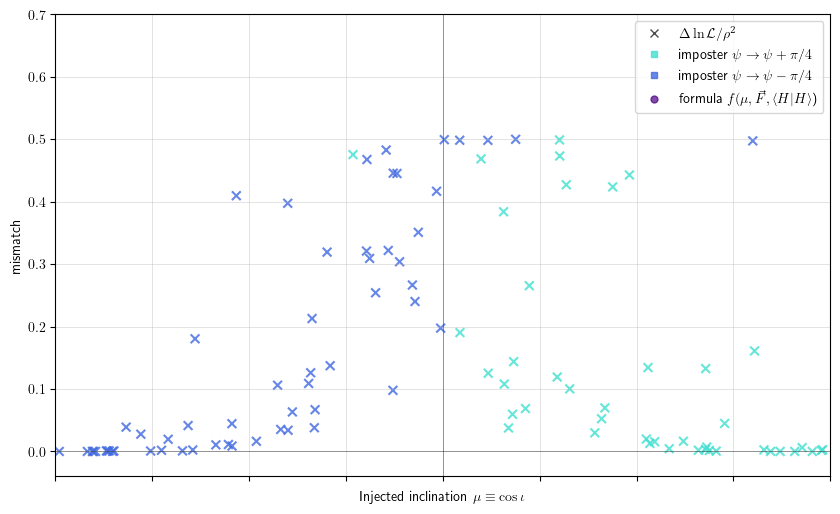

In [10]:
legend_labels = [r"$\Delta\ln\mathcal L/\rho^2$",
                 r'formula $f(\mu, \vec F,\langle H|H\rangle$)']

# does the difference in LHS and RHS depend on inclination?
fig, ax = plt.subplots(figsize=(10,6))

# let's color the injections by the best imposter (± π/4)
c1, c2 = 'turquoise', 'royalblue'
colors = np.full(len(mus), c1)
colors[idx_neg] = c2

lnlike_mis = np.array(list(lnlike_mismatches.values()))
ax.scatter(mus, lnlike_mis,
                c=colors, label=legend_labels[0], marker='x', alpha=0.8, s=40)
ax.set_ylim(-.04, 0.7)
ax.set_xlabel(r'Injected inclination $\mu\equiv\cos\iota$')
_ = ax.set_xticklabels([])
ax.set_ylabel('mismatch')
ax.set_xlim(-1., 1.)
ax.axvline(0., c='k', alpha=0.5, lw=0.5)
ax.grid(alpha=0.5, lw=0.5)
ax.axhline(0., c='k', lw=0.5, alpha=0.5)

# custom legend
labels = [r"$\Delta\ln\mathcal L/\rho^2$",
          r'imposter $\psi\rightarrow\psi +\pi/4$',
          r'imposter $\psi\rightarrow\psi -\pi/4$',
          legend_labels[1]]
handles = [Line2D([0], [0], marker='x', alpha=0.7, ms=6, c='k', ls='None'),
           Line2D([0], [0], alpha=0.8, ms=5, marker='s', ls='None', c=c1),
           Line2D([0], [0], alpha=0.8, ms=5, marker='s', ls='None', c=c2),
           Line2D([0], [0], alpha=0.7, ms=5, marker='o', ls='None', c='indigo')]
ax.legend(labels=labels, handles=handles)

In [18]:
# count the number of events with the opposite imposter as expected
outliers = []
for (idx, shift), mu in zip(imposters.items(), mus):
    if np.sign(shift) != np.sign(mu):
        outliers.append(idx)

In [19]:
len(outliers)

6